<a href="https://colab.research.google.com/github/Susmitapaul45/Air_Quality_Dhaka_city/blob/main/Air_quality_AdaBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving air_quality_dataset.csv to air_quality_dataset.csv
Accuracy: 96.82%
Precision: 99.36%
Recall: 81.25%
F1 Score: 89.40%
Confusion Matrix:
[[970   1]
 [ 36 156]]


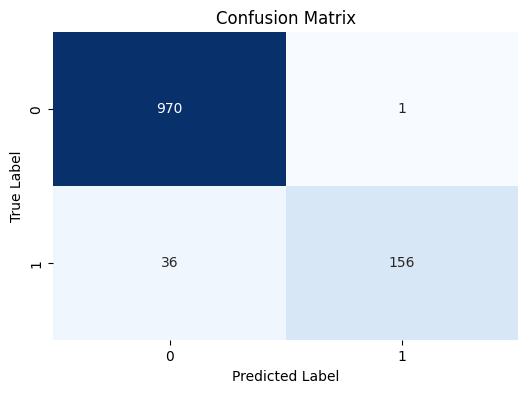

AUC: 0.91


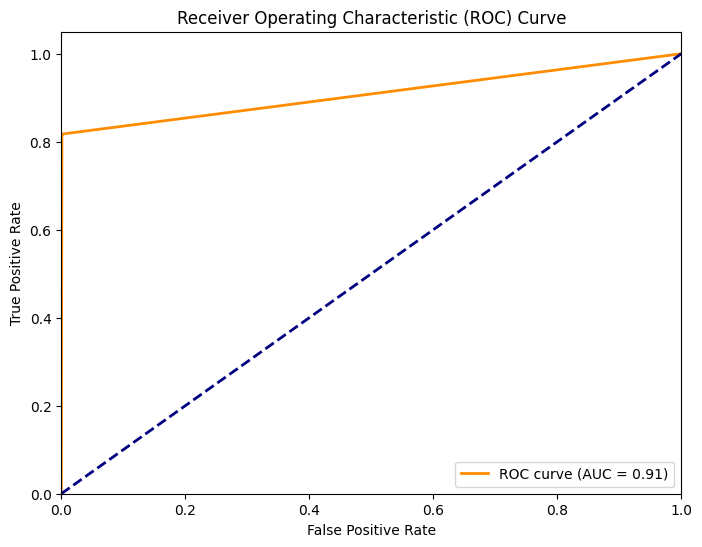

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import StandardScaler

# Upload the dataset (this works in Colab)
from google.colab import files
uploaded = files.upload()

# Load the dataset
dataset = pd.read_csv("/content/air_quality_dataset.csv")
array = dataset.values

# Select features and target column
X = array[:, 1:13]
Y = array[:, 13]

# Convert the continuous target into a binary class label using the median as threshold.
threshold = np.median(Y)
y_class = (Y > threshold).astype(int)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=100)

# Standardize features for better performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train an AdaBoost Classifier with DecisionTree as base estimator
base_estimator = DecisionTreeClassifier(max_depth=1)  # Weak learner (stump)
model = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.1, random_state=100)
model.fit(X_train, y_train)


# Make predictions and obtain probabilities for the positive class
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred) * 100
precision = precision_score(y_test, y_pred) * 100
recall = recall_score(y_test, y_pred) * 100
f1 = f1_score(y_test, y_pred) * 100

print(f'Accuracy: {accuracy:.2f}%')
print(f'Precision: {precision:.2f}%')
print(f'Recall: {recall:.2f}%')
print(f'F1 Score: {f1:.2f}%')

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print(f'AUC: {roc_auc:.2f}')

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


In [ ]:
#Feature Extraction
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.feature_selection import RFE
from google.colab import files

# Upload the dataset
uploaded = files.upload()

# Load the dataset
dataset = pd.read_csv("/content/air_quality_dataset.csv")
array = dataset.values

# Select features and target column
X = array[:, 1:13]
Y = array[:, 13]

# Convert target into a binary class label using median threshold
threshold = np.median(Y)
y_class = (Y > threshold).astype(int)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=100)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Base estimator for AdaBoost
base_estimator = DecisionTreeClassifier(max_depth=1)

# ---------------------- PCA ---------------------- #
pca = PCA(n_components=0.95)  # Retain 95% variance
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

model_pca = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.1, random_state=100)
model_pca.fit(X_train_pca, y_train)
y_pred_pca = model_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca) * 100
print(f'PCA Model Accuracy: {accuracy_pca:.2f}%')

# ---------------------- LDA ---------------------- #
lda = LDA(n_components=1)  # Maximum components for binary classification
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

model_lda = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.1, random_state=100)
model_lda.fit(X_train_lda, y_train)
y_pred_lda = model_lda.predict(X_test_lda)
accuracy_lda = accuracy_score(y_test, y_pred_lda) * 100
print(f'LDA Model Accuracy: {accuracy_lda:.2f}%')

# ---------------------- RFE ---------------------- #
rfe = RFE(estimator=DecisionTreeClassifier(), n_features_to_select=5)  # Select top 5 features
X_train_rfe = rfe.fit_transform(X_train, y_train)
X_test_rfe = rfe.transform(X_test)

model_rfe = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.1, random_state=100)
model_rfe.fit(X_train_rfe, y_train)
y_pred_rfe = model_rfe.predict(X_test_rfe)
accuracy_rfe = accuracy_score(y_test, y_pred_rfe) * 100
print(f'RFE Model Accuracy: {accuracy_rfe:.2f}%')



Saving air_quality_dataset.csv to air_quality_dataset.csv
PCA Model Accuracy: 93.55%
LDA Model Accuracy: 96.47%
RFE Model Accuracy: 96.82%


Saving air_quality_dataset.csv to air_quality_dataset.csv
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'estimator__max_depth': 1, 'learning_rate': 0.01, 'n_estimators': 50}
Accuracy: 96.82%
Precision: 99.36%
Recall: 81.25%
F1 Score: 89.40%
Confusion Matrix:
[[970   1]
 [ 36 156]]


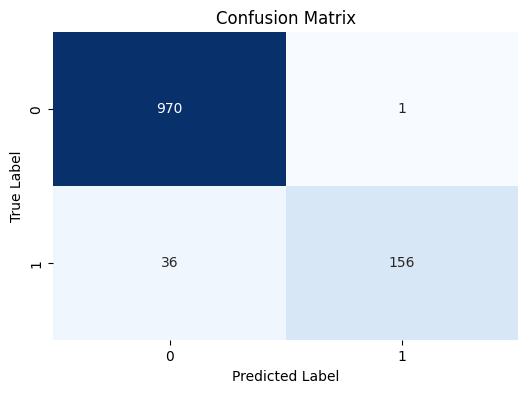

AUC: 0.91


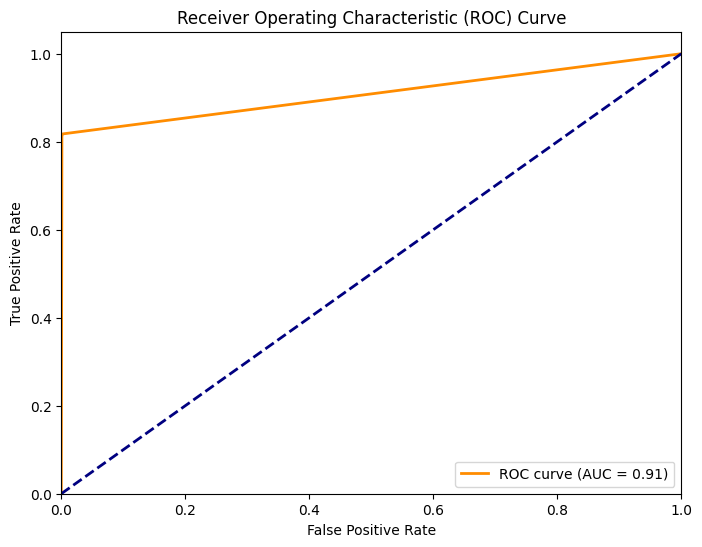

In [ ]:
#Cross-Validation and Hyperparameter tuning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import StandardScaler

# Upload the dataset (this works in Colab)
from google.colab import files
uploaded = files.upload()

# Load the dataset
dataset = pd.read_csv("/content/air_quality_dataset.csv")
array = dataset.values

# Select features and target column
X = array[:, 1:13]
Y = array[:, 13]

# Convert the continuous target into a binary class label using the median as threshold.
threshold = np.median(Y)
y_class = (Y > threshold).astype(int)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=100)

# Standardize features for better performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of boosting rounds
    'learning_rate': [0.01, 0.1, 0.5, 1],  # Step size
    'estimator__max_depth': [1, 2, 3]  # Depth of weak learner (stump)
}

# Initialize AdaBoost Classifier with a Decision Tree base estimator
base_estimator = DecisionTreeClassifier()
adaboost = AdaBoostClassifier(estimator=base_estimator, random_state=100)

# Apply GridSearchCV with 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=100)
grid_search = GridSearchCV(adaboost, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=2)

# Train the model with the best parameters
grid_search.fit(X_train, y_train)

# Get the best parameters
print("Best Parameters:", grid_search.best_params_)

# Train the final model using the best parameters
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred) * 100
precision = precision_score(y_test, y_pred) * 100
recall = recall_score(y_test, y_pred) * 100
f1 = f1_score(y_test, y_pred) * 100

print(f'Accuracy: {accuracy:.2f}%')
print(f'Precision: {precision:.2f}%')
print(f'Recall: {recall:.2f}%')
print(f'F1 Score: {f1:.2f}%')

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print(f'AUC: {roc_auc:.2f}')

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
